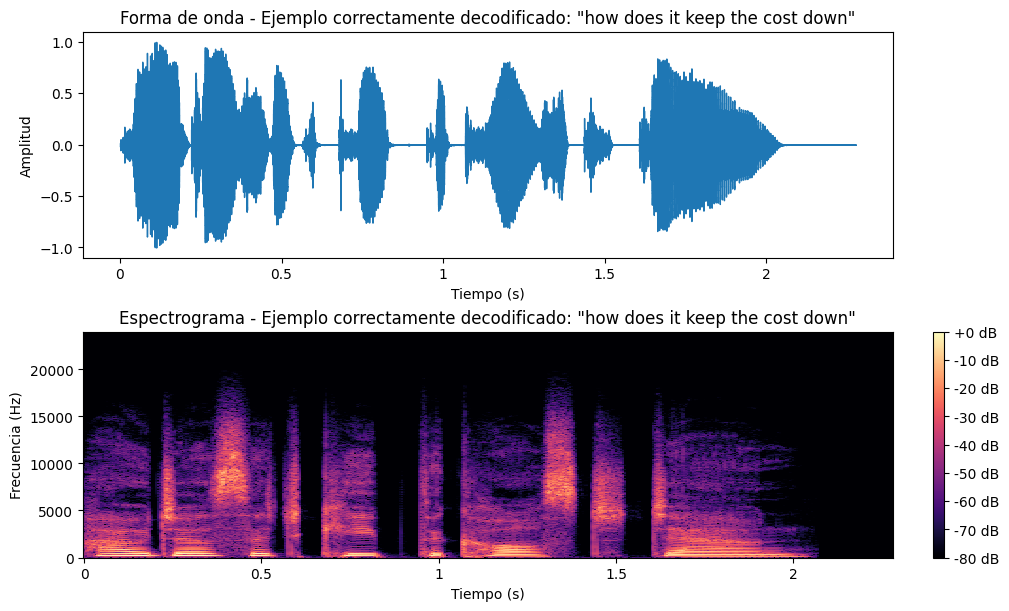

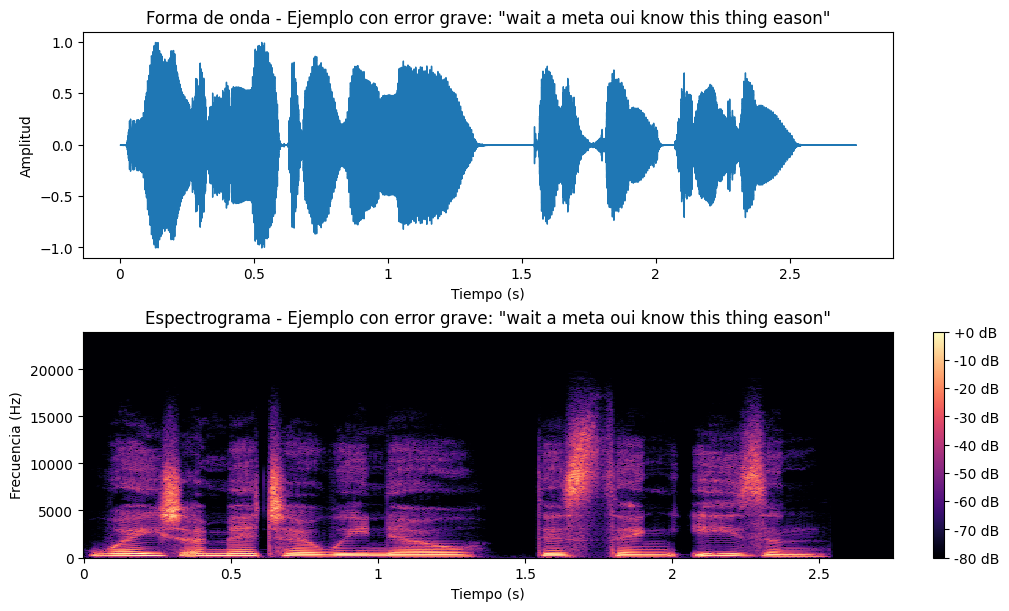

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

audio_good = Path("example_001.wav")
audio_bad = Path("example_010.wav")

examples = [
    (audio_good, "Ejemplo correctamente decodificado: \"how does it keep the cost down\""),
    (audio_bad, "Ejemplo con error grave: \"wait a meta oui know this thing eason\"")
]

for audio_path, title in examples:
    y, sr = librosa.load(audio_path, sr=None)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Forma de onda
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Forma de onda - {title}")
    axes[0].set_xlabel("Tiempo (s)")
    axes[0].set_ylabel("Amplitud")

    # Espectrograma
    S = librosa.stft(y, n_fft=1024, hop_length=256)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    img = librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=256,
        x_axis="time",
        y_axis="hz",
        ax=axes[1]
    )
    axes[1].set_title(f"Espectrograma - {title}")
    axes[1].set_xlabel("Tiempo (s)")
    axes[1].set_ylabel("Frecuencia (Hz)")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

    # Guardar una única figura por ejemplo
    plt.savefig(audio_path.with_suffix(".combined.png"), dpi=300, bbox_inches="tight")
    plt.show()